In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
pd.set_option('display.max_columns', None)

In [2]:
# Carga de datasets

df_flight_activity = pd.read_csv("files_limpios/customer_flight_activity_limpio.csv")

df_flight_activity.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0.0,0
1,100102,2017,1,10,4,14,2030,203.0,0.0,0


In [3]:
df_loyalty = pd.read_csv("files_limpios/customer_loyalty_history_limpio.csv")

df_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.000000,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,79429.572642,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


In [4]:
df_unido = pd.read_csv("files_limpios/customer_completo_limpio.csv")

df_unido.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,1,3,0,3,1521,152.0,0.0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.000000,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0.0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,79429.572642,Single,Nova,2887.74,Standard,2013,3,NaN,NaN


# 3) Visualización:

### A continuación contestaremos las siguientes preguntas usando herramientas de visualización.

##### 1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

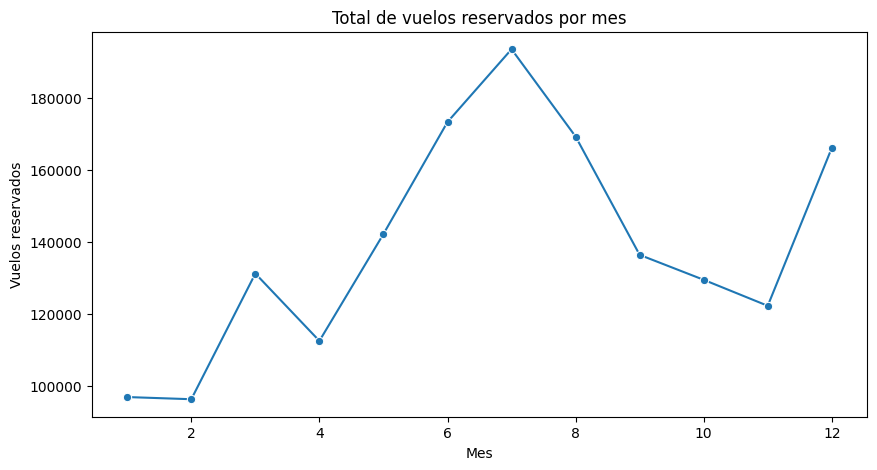

In [26]:
# Agrupamos por mes y sumamos vuelos
flights_by_month = df_flight_activity.groupby('month')['flights_booked'].sum().reset_index()

plt.figure(figsize=(10,5))

# Gráfico de línea para ver evolución temporal
sns.lineplot(data=flights_by_month, x='month', y='flights_booked', marker='o')

# personalizamos
plt.title('Total de vuelos reservados por mes')
plt.xlabel('Mes')
plt.ylabel('Vuelos reservados')

plt.show();

In [ ]:
# Observación: Hay una variación de vuelos a lo largo de los meses, podría verse influenciado por las estaciones (verano), vacaciones (navidad, año nuevo)

#### 2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

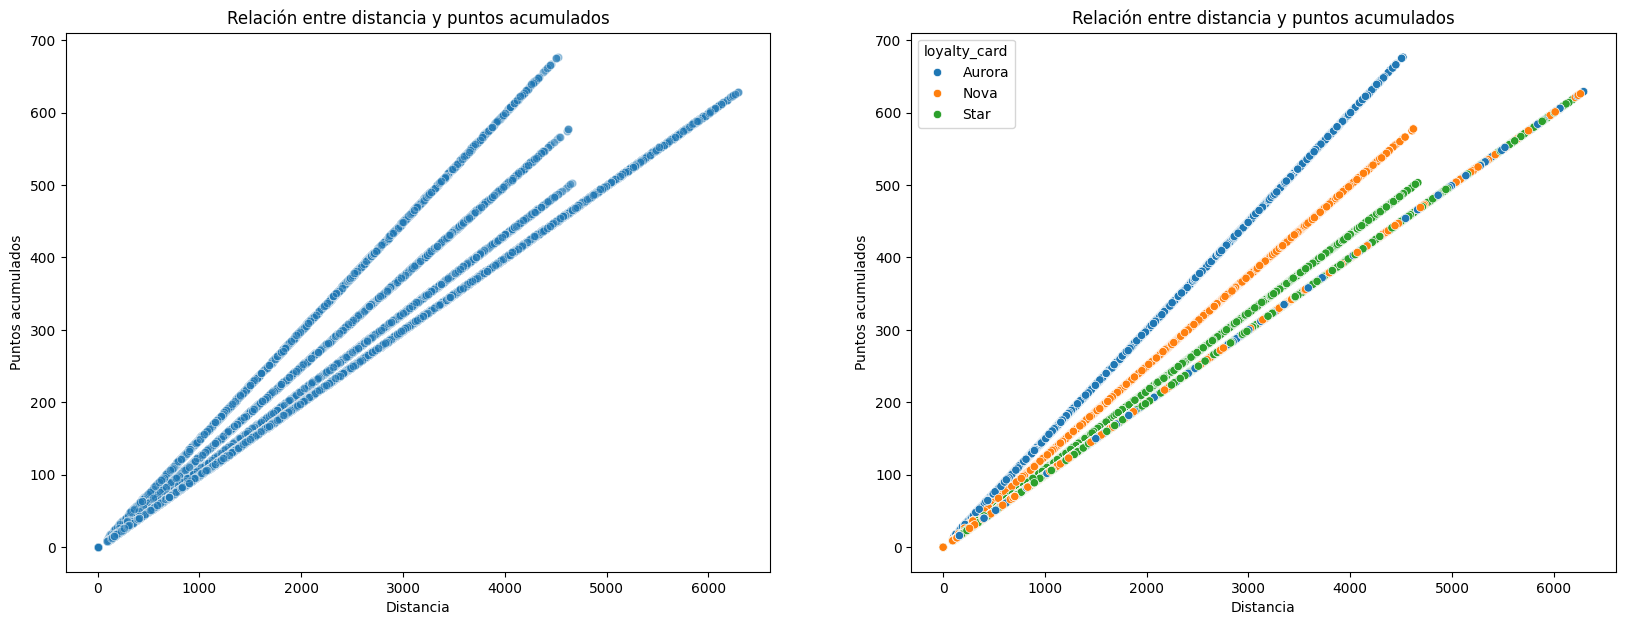

In [61]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize =(20,7))

# Scatterplot nos sirve porque estamos viendo relaciones entre variables numéricas
sns.scatterplot(data=df_flight_activity, x='distance', y='points_accumulated', alpha=0.5, ax=axes[0])

axes[0].set_title('Relación entre distancia y puntos acumulados')
axes[0].set_xlabel('Distancia')
axes[0].set_ylabel('Puntos acumulados')

# siempre un scatterplot pero añadiendo otra variable categorica (loyalty_card), para ver si hay relación
sns.scatterplot(data=df_unido, x='distance', y='points_accumulated', hue='loyalty_card', ax=axes[1])
axes[1].set_title('Relación entre distancia y puntos acumulados')
axes[1].set_xlabel('Distancia')
axes[1].set_ylabel('Puntos acumulados')

plt.show();

In [ ]:
# Observación: En los gráficos podemos ver una relación positiva entre la distancia recorrida y los puntos acumulados, entre mas distancia recorrida mayor la cantidad de puntos acumulados.
# Se entiende que es el funcionamiento de un programa de fidelización.
# Se crearon dos gráficos, el segundo incluyendo la variable categórica (loyalty_card), ya que está relacionada con el programa de fidelización. Nuevamente podemos ver que hay bastante relación entre las variables,
# y que dependiendo del tipo de tarjeta que posea el cliente, acumulan más puntos con menor distancia recorrida.

##### 3. ¿Cuál es la distribución de los clientes por provincia o estado?

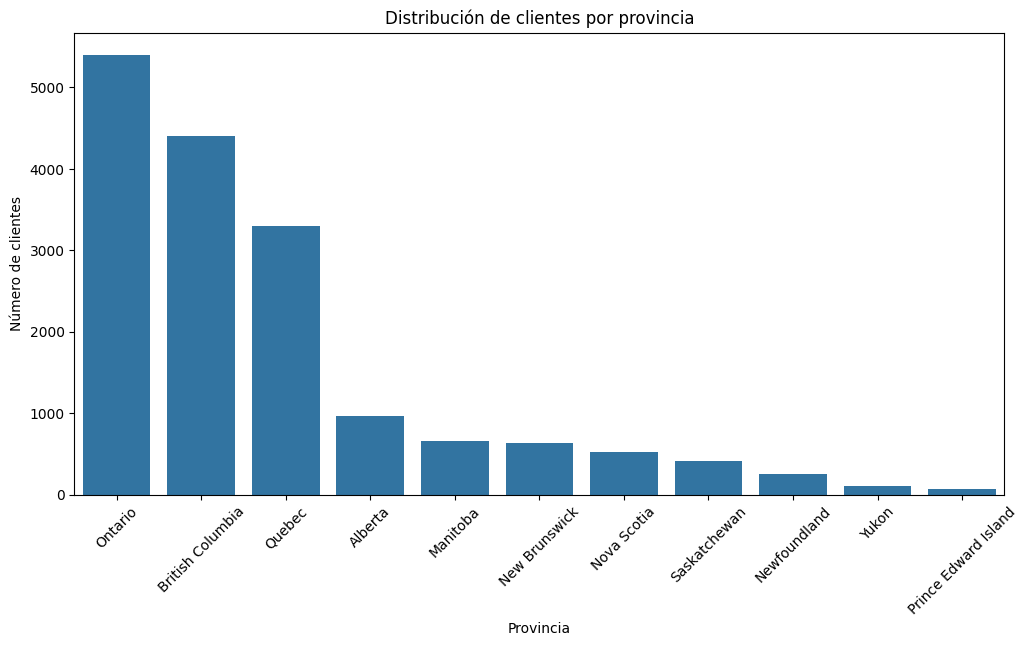

In [24]:
# usaremos un barplot porque estamos viendo la relacion entre una variable categorica (provincia) y una numerica (clientes)
plt.figure(figsize=(12,6))

# Contamos clientes únicos por provincia y que salgan en orden
province_counts = df_loyalty['province'].value_counts()

sns.barplot(x=province_counts.index, y=province_counts.values)

plt.title('Distribución de clientes por provincia')
plt.xlabel('Provincia')
plt.ylabel('Número de clientes')


plt.xticks(rotation=45)

plt.show();

In [ ]:
# Observación: La distribución de los clientes se concentra mayormente en Ontario, British Columbia y Quebec. Podría ser por mayor densidad de población en dichas provincias.

##### 4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

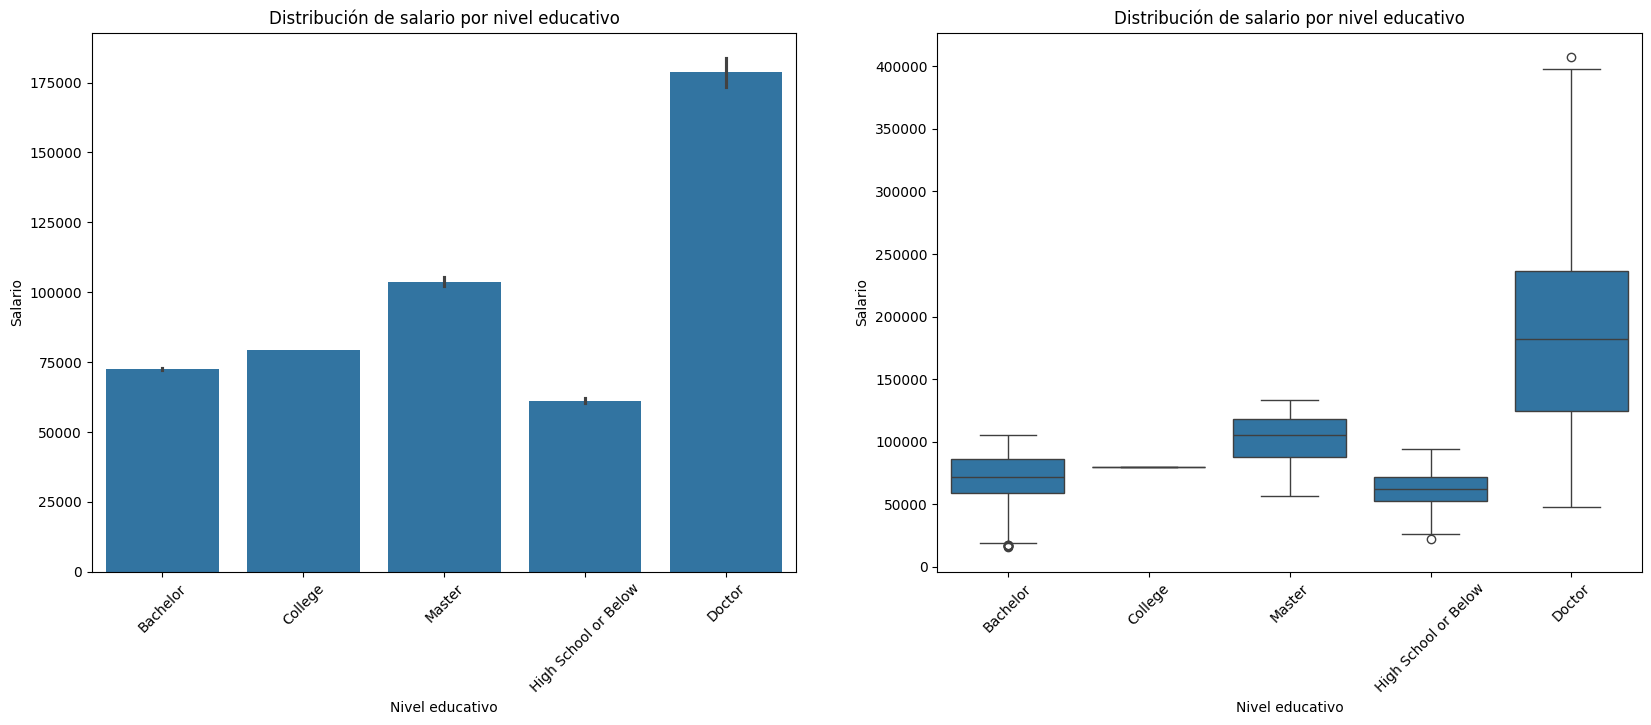

In [60]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize =(20,7))

# barplot para ver los promedios de la variable numérica (salario) dentro de cada categoría de education
sns.barplot(data=df_loyalty, x='education', y='salary', estimator='mean', ax=axes[0])

axes[0].set_title('Distribución de salario por nivel educativo')
axes[0].set_xlabel('Nivel educativo')
axes[0].set_ylabel('Salario')
axes[0].tick_params(axis="x", rotation=45)


# en este caso queriamos ver promedios, pero tomando en cuenta que en college se encontraban bastantes nulos, haremos un boxplot para ver distribucion

sns.boxplot(data=df_loyalty, x='education', y='salary', ax=axes[1])

axes[1].set_title('Distribución de salario por nivel educativo')
axes[1].set_xlabel('Nivel educativo')
axes[1].set_ylabel('Salario')
axes[1].tick_params(axis="x", rotation=45)

plt.show();

In [ ]:
# Observación: Podemos ver que a mayor nivel educativo tiende a ser mayor el salario, aunque dentro de cada categoria podemos ver que hay datos variados.
# Con el boxplot vemos que no todos los salarios son considerablemente altos, pero hay unos cuantos que si lo son (outliers), por lo tanto influyen el promedio.

#### 5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

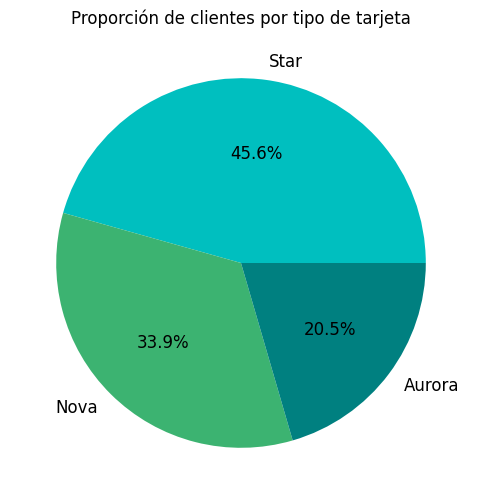

In [53]:
counts = df_loyalty['loyalty_card'].value_counts()
colores = ["c","mediumseagreen","teal", "turquoise", "lightseagreen", "lightblue"]

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=colores,
    textprops={"fontsize":12}
)

plt.title('Proporción de clientes por tipo de tarjeta')

plt.show();

In [ ]:
# hacemos la variable counts ya que matplotlib no trabaja con df
# Observación: Usamos un pie plot para ver las proporciones en porcentajes. Podemos ver que la mayoría de los clientes poseen la tarjeta Star, está podría ser la tarjeta más básica/fácil de obtener de programa de fidelización

#### 6. ¿Cómo se distribuyen los clientes según su estado civil y género?

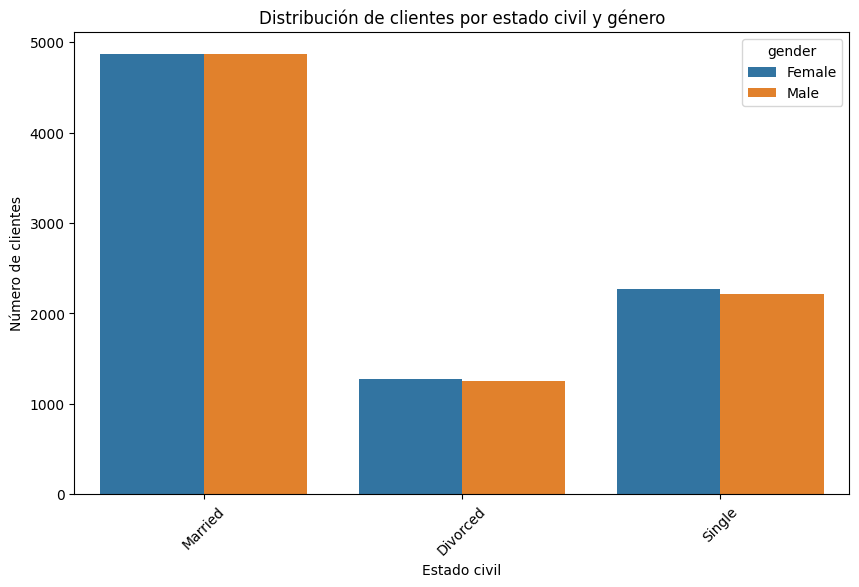

In [42]:
plt.figure(figsize=(10,6))

sns.countplot(data=df_loyalty, x='marital_status', hue='gender')

plt.title('Distribución de clientes por estado civil y género')
plt.xlabel('Estado civil')
plt.ylabel('Número de clientes')

plt.xticks(rotation=45)

plt.show();

In [ ]:
# Observación: La mayoría de los clientes son casados y su distribución por genero es casi que igual. Este dato podría usarse para crear incentivos especificos para parejas dentro del programa de fidelización.
# O para crear campañas de captación para aumentar las categorias de clientes solteros y divorciados.